# 1. Data Preparation
- Data Exploration: Conduct a thorough initial analysis using descriptive statistics and visualizations. What does the data tell you about each feature's distribution and the presence of outliers
- Feature Engineering: Create new features that could be predictive of diabetes, such as interactions between existing features (e.g., Glucose-to-Insulin ratio).
- Handling Missing Values: Require an exploration of different methods for handling missing values. Should they impute, remove, or use indicators for missingness? Justify the chosen method.
- Data Transformation: Discuss the need for and implement scaling or normalization, especially for distance-based algorithms like KNN.
- Dataset Splitting: Discuss the impact of the split ratio on model performance and overfitting.


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

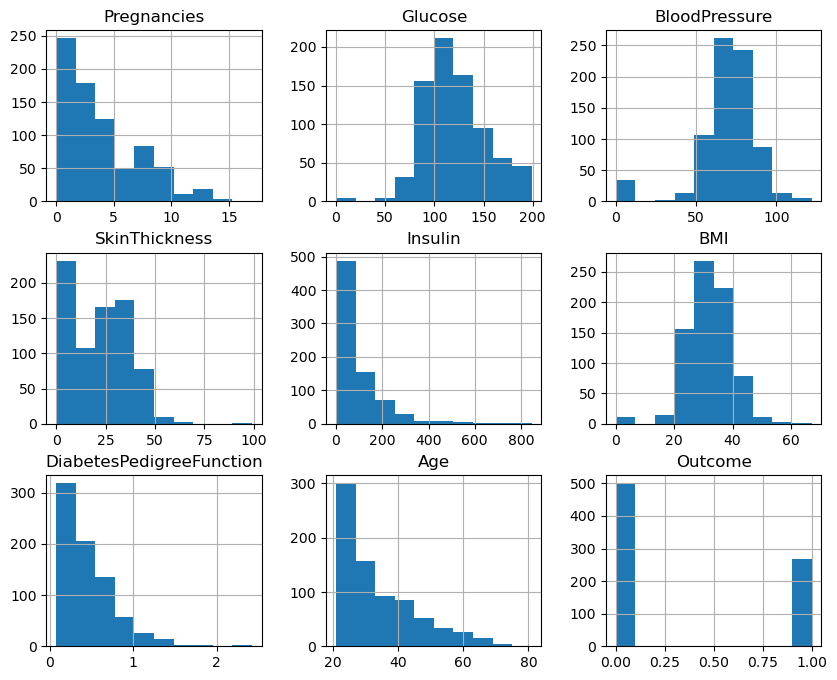

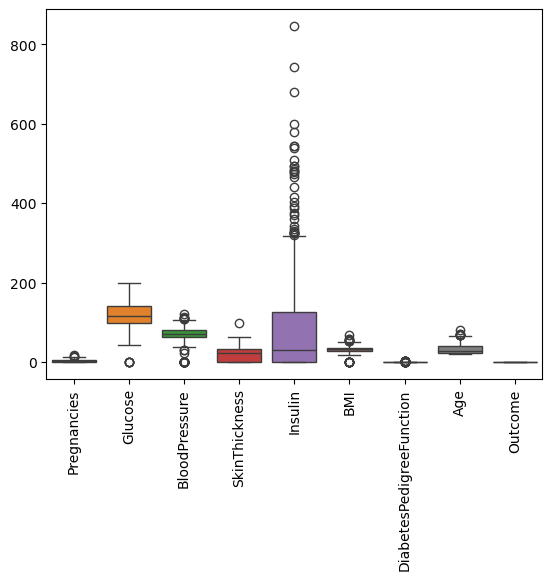

In [68]:
# Data Exploration:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")

# Summary statistics
print(df.head())
print(df.info())
print(df.describe())

# Histograms
df.hist(figsize=(10,8))
plt.show()

# Boxplots for outliers
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [69]:
#Feature Engineering

df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1)
df['BMI_Age'] = df['BMI'] * df['Age']

In [70]:
# Handling missing values

import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

In [71]:
# Data Transformation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_scaled = scaler.fit_transform(X)

In [72]:
# Data splitting

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (614, 10)
Test size: (154, 10)


# 2. Decision Tree Classifier:
- Implement a decision tree classifier. What hyperparameters did you choose to optimize, and why?
- Evaluate and report the performance of the decision tree model.


In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# train
dt.fit(X_train, y_train)

# predict
y_pred_dt = dt.predict(X_test)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7467532467532467

Confusion Matrix:
[[88 11]
 [25 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        99
           1       0.73      0.55      0.62        55

    accuracy                           0.77       154
   macro avg       0.76      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



# 3. Random Forest Classifier:
- Build a random forest classifier. How did you determine the number of trees to use?
- Assess the random forest model’s performance. How does it compare to the decision tree in terms of accuracy?
- Identify the most important features according to the random forest model.


In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Comparison of decision tree to random forest model
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7532467532467533

Confusion Matrix:
[[80 19]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


Decision Tree Accuracy: 0.7662337662337663
Random Forest Accuracy: 0.7532467532467533


In [75]:
# Feature importance

importances = rf.feature_importances_
features = X.columns

for f, imp in zip(features, importances):
    print(f, imp)

Pregnancies 0.04971275402288778
Glucose 0.20843418076598103
BloodPressure 0.06361213752495468
SkinThickness 0.051308880017155195
Insulin 0.06605258016157627
BMI 0.12278507404299603
DiabetesPedigreeFunction 0.09134193983667344
Age 0.0909172873863186
Glucose_Insulin_Ratio 0.10350405596472123
BMI_Age 0.15233111027673585


# 4. K-Nearest Neighbors (KNN) Classifier:
- Create a KNN classifier. How did you select the value of K?
- Evaluate the KNN model's performance. What are the precision and recall values?
- Experiment with different values of K. How does changing K affect the model's performance?
- Impact of Feature Scaling: Specifically analyze the performance before and after scaling. Why is scaling crucial for KNN?


In [76]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [77]:
from sklearn.metrics import precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))

Accuracy: 0.7272727272727273
Precision: 0.6382978723404256
Recall: 0.5454545454545454


In [78]:
# Experiment with Different K Values in KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt

# Store results
k_values = list(range(1, 21))
results = []

for k in k_values:
    # Create model with current K
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predictions
    y_pred = knn.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    # Store results
    results.append({
        "K": k,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

     K  Accuracy  Precision    Recall
0    1  0.636364   0.492063  0.563636
1    2  0.675325   0.586207  0.309091
2    3  0.727273   0.614035  0.636364
3    4  0.688312   0.594595  0.400000
4    5  0.707792   0.592593  0.581818
5    6  0.707792   0.638889  0.418182
6    7  0.727273   0.638298  0.545455
7    8  0.707792   0.631579  0.436364
8    9  0.701299   0.595745  0.509091
9   10  0.701299   0.609756  0.454545
10  11  0.740260   0.653061  0.581818
11  12  0.733766   0.652174  0.545455
12  13  0.740260   0.641509  0.618182
13  14  0.727273   0.632653  0.563636
14  15  0.714286   0.603774  0.581818
15  16  0.746753   0.673913  0.563636
16  17  0.733766   0.640000  0.581818
17  18  0.753247   0.697674  0.545455
18  19  0.759740   0.704545  0.563636
19  20  0.766234   0.731707  0.545455


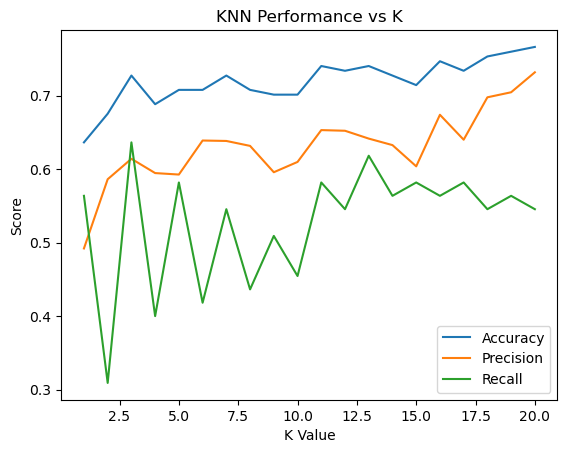

In [79]:
# Plot performance vs K
plt.figure()

plt.plot(results_df["K"], results_df["Accuracy"], label="Accuracy")
plt.plot(results_df["K"], results_df["Precision"], label="Precision")
plt.plot(results_df["K"], results_df["Recall"], label="Recall")

plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()

plt.show()

In [80]:
# Impact of Feature Scaling on KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. WITHOUT SCALING
# Use original (unscaled) data
X_train_ns, X_test_ns = X_train.copy(), X_test.copy()

knn_no_scale = KNeighborsClassifier(n_neighbors=7)
knn_no_scale.fit(X_train_ns, y_train)

y_pred_ns = knn_no_scale.predict(X_test_ns)

# Metrics without scaling
results_no_scale = {
    "Model": "KNN (No Scaling)",
    "Accuracy": accuracy_score(y_test, y_pred_ns),
    "Precision": precision_score(y_test, y_pred_ns),
    "Recall": recall_score(y_test, y_pred_ns)
}


# 2. WITH SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_ns)
X_test_scaled = scaler.transform(X_test_ns)

knn_scaled = KNeighborsClassifier(n_neighbors=7)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

# Metrics with scaling
results_scaled = {
    "Model": "KNN (With Scaling)",
    "Accuracy": accuracy_score(y_test, y_pred_scaled),
    "Precision": precision_score(y_test, y_pred_scaled),
    "Recall": recall_score(y_test, y_pred_scaled)
}


# 3. Compare Results
comparison_df = pd.DataFrame([results_no_scale, results_scaled])

print("\nKNN Performance Comparison (Before vs After Scaling):")
print(comparison_df)


KNN Performance Comparison (Before vs After Scaling):
                Model  Accuracy  Precision    Recall
0    KNN (No Scaling)  0.727273   0.638298  0.545455
1  KNN (With Scaling)  0.720779   0.625000  0.545455


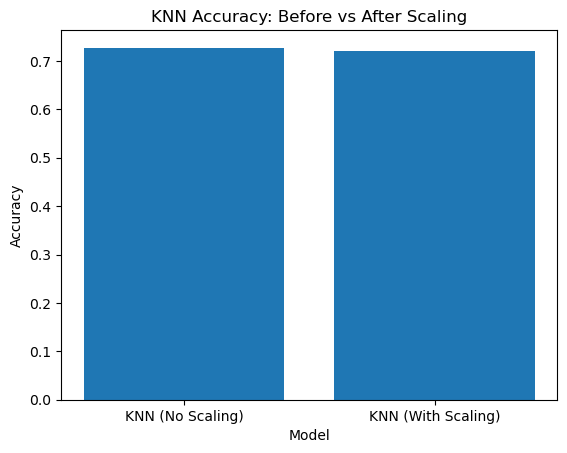

In [81]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("KNN Accuracy: Before vs After Scaling")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

# 5. Model Comparison and Selection:
- Compare the accuracy of the three models. Which model performs the best on these metrics?
- Discuss the advantages and disadvantages of each model in the context of this dataset.
- If you had to choose one model to use in a clinical setting to predict diabetes, which one would it be and why?


In [82]:
# Model Comparision and Selection

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Function to compute metrics
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# Evaluate all models
results = []

results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("KNN", y_test, y_pred_knn))

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results)

# Display results
print("\nModel Comparison:")
print(results_df)

# Find best model based on accuracy
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("\nBest Model Based on Accuracy:")
print(best_model)

# Optional: Sort results
results_df_sorted = results_df.sort_values(by="Accuracy", ascending=False)
print("\nSorted Results:")
print(results_df_sorted)


Model Comparison:
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.746753   0.653846  0.618182  0.635514
1  Random Forest  0.753247   0.654545  0.654545  0.654545
2            KNN  0.766234   0.731707  0.545455  0.625000

Best Model Based on Accuracy:
Model             KNN
Accuracy     0.766234
Precision    0.731707
Recall       0.545455
F1 Score        0.625
Name: 2, dtype: object

Sorted Results:
           Model  Accuracy  Precision    Recall  F1 Score
2            KNN  0.766234   0.731707  0.545455  0.625000
1  Random Forest  0.753247   0.654545  0.654545  0.654545
0  Decision Tree  0.746753   0.653846  0.618182  0.635514


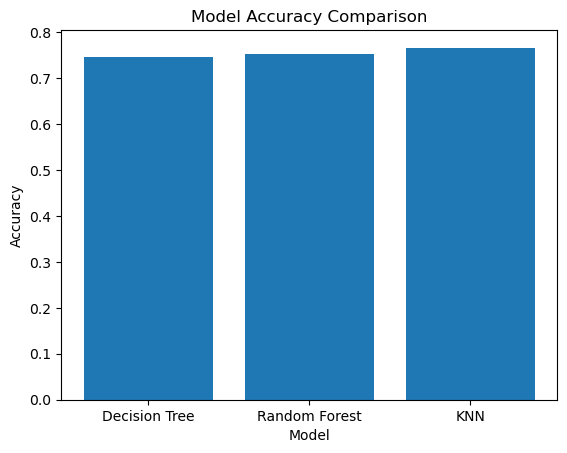

In [83]:
import matplotlib.pyplot as plt

# Plot accuracy comparison
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

Evaluation Criteria:
- Depth of data understanding and EDA.
- Creativity and effectiveness in data preprocessing.
- Logical reasoning in model selection.
- Model performance on the validation set.
- Quality of the presentation and report.
